# Word Embeddings

## Importing Libraries and Loading Data

In [4]:
import re
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import pandas as pd
from collections import Counter
from nltk.corpus import stopwords
import nltk
from wordcloud import WordCloud

stop_words = set(stopwords.words('english'))

In [5]:
with open('Data/Corpus.txt', 'r', encoding="utf-8") as f:
    text = f.read()

## Preprocessing and Statistics of Data

In [7]:
def preprocess_sentences(text):
    
    # Lowercase
    text = text.lower()

    # Remove URLs/emails
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    # sentence tokenization
    sentences = re.split(r'[.!?\n]', text)

    processed = []

    for sent in sentences:
        
        #  Keep only alphabets
        sent = re.sub(r'[^a-z\s]', ' ', sent)
        sent = re.sub(r'\s+', ' ', sent).strip()

        tokens = sent.split()  # split sentence to words

        tokens = [
            t for t in tokens 
            if t not in stop_words and len(t) >= 2  # stopword removal
        ]

        if len(tokens) >= 3:   # keep meaningful sentences
            processed.append(tokens)

    return processed

In [8]:
sentences = preprocess_sentences(text)

print("Number of sentences:", len(sentences))
print(sentences[:3])

Number of sentences: 47904
[['indian', 'institute', 'technology', 'jodhpur'], ['department', 'computer', 'science', 'engineering'], ['dual', 'degree', 'programs']]


In [9]:
# statistics of data

num_docs = len(sentences)
tokens = [w for sent in sentences for w in sent]
num_tokens = len(tokens)
vocab = set(tokens)
vocab_size = len(vocab)

print("Total documents (sentences):", num_docs)
print("Total tokens:", num_tokens)
print("Vocabulary size:", vocab_size)

Total documents (sentences): 47904
Total tokens: 304637
Vocabulary size: 15876


In [10]:
# count frequent words

word_freq = Counter(tokens)

print("Top 10 most frequent words:")
for word, freq in word_freq.most_common(10):
    print(f"{word}: {freq}")

Top 10 most frequent words:
lectures: 4901
engineering: 2853
design: 2783
systems: 2257
course: 1984
analysis: 1859
introduction: 1840
energy: 1760
xx: 1696
department: 1603


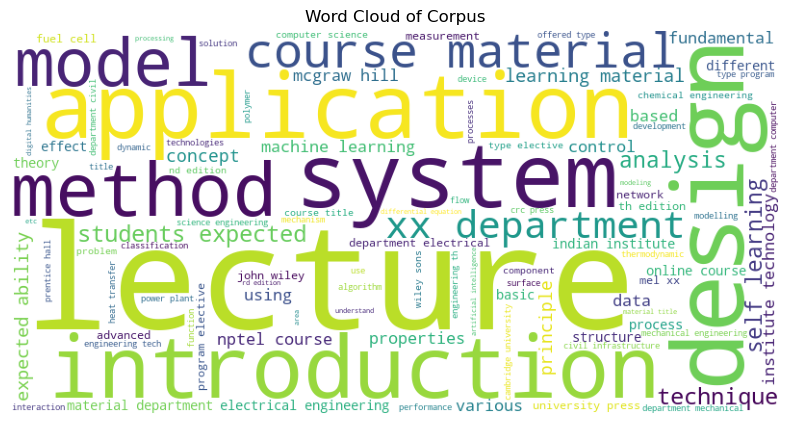

In [11]:
# Word Cloud Visualization

text_for_wc = " ".join(tokens)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(text_for_wc)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Corpus")
plt.show()

## Training and Comparison

In [13]:
embedding_dims = [100, 150, 300]
window_sizes = [5, 10]
negative_samples = [10, 15]

all_models = []

for sg in [0, 1]:  # 0=CBOW, 1=Skipgram
    for dim in embedding_dims: # [100,150,300]
        for window in window_sizes: #[5,10]
            for neg in negative_samples: #[10,15]
                
                model = Word2Vec(sentences=sentences,vector_size=dim,window=window,min_count=1,workers=4,sg=sg,negative=neg,epochs=10) # train for each config
                
                config = {
                    "type": "CBOW" if sg == 0 else "Skipgram",
                    "dim": dim,
                    "window": window,
                    "neg": neg
                }
                
                all_models.append((config, model)) # save each model to evaluate and compare later
                
                print("Trained:", config)

Trained: {'type': 'CBOW', 'dim': 100, 'window': 5, 'neg': 10}
Trained: {'type': 'CBOW', 'dim': 100, 'window': 5, 'neg': 15}
Trained: {'type': 'CBOW', 'dim': 100, 'window': 10, 'neg': 10}
Trained: {'type': 'CBOW', 'dim': 100, 'window': 10, 'neg': 15}
Trained: {'type': 'CBOW', 'dim': 150, 'window': 5, 'neg': 10}
Trained: {'type': 'CBOW', 'dim': 150, 'window': 5, 'neg': 15}
Trained: {'type': 'CBOW', 'dim': 150, 'window': 10, 'neg': 10}
Trained: {'type': 'CBOW', 'dim': 150, 'window': 10, 'neg': 15}
Trained: {'type': 'CBOW', 'dim': 300, 'window': 5, 'neg': 10}
Trained: {'type': 'CBOW', 'dim': 300, 'window': 5, 'neg': 15}
Trained: {'type': 'CBOW', 'dim': 300, 'window': 10, 'neg': 10}
Trained: {'type': 'CBOW', 'dim': 300, 'window': 10, 'neg': 15}
Trained: {'type': 'Skipgram', 'dim': 100, 'window': 5, 'neg': 10}
Trained: {'type': 'Skipgram', 'dim': 100, 'window': 5, 'neg': 15}
Trained: {'type': 'Skipgram', 'dim': 100, 'window': 10, 'neg': 10}
Trained: {'type': 'Skipgram', 'dim': 100, 'window':

In [14]:
word = "course"   

model = Word2Vec(sentences=sentences,vector_size=300,window=window,min_count=1,workers=4,sg=1,negative=5,epochs=10) # create a model with vector dim = 300
vector = model.wv[word] # get the vector of specified word

# format as comma-separated
vector_str = ", ".join([f"{v:.4f}" for v in vector])

print(f"{word} - {vector_str}")

course - 0.1039, 0.0663, 0.4451, -0.3602, 0.2735, -0.1028, 0.1804, 0.9015, 0.2196, -0.6224, 0.0346, -0.2524, -0.7151, 0.1067, -0.4077, -0.4920, 0.4366, 0.0464, 0.3051, -0.0297, -0.1582, -0.1874, 0.1398, 0.6874, 0.1308, -0.2955, -0.7068, -0.0159, -0.1796, -0.0662, -0.1192, -0.2374, 0.0303, -0.0585, -0.3588, -0.0829, -0.2410, 0.0613, 0.4070, 0.0572, -0.1404, 0.2228, 0.0728, 0.2104, 0.3720, -0.1340, 0.3627, 0.2417, -0.3148, 0.6113, 0.1860, 0.1013, -0.3084, -0.3600, 0.3098, 0.2863, 0.3297, -0.1847, 0.7006, 0.1011, -0.3125, -0.3375, 0.1665, 0.1718, -0.2192, -0.0362, -0.1046, -0.2081, -0.3018, 0.1851, 0.0809, -0.2546, 0.1791, -0.1833, 0.1356, -0.1255, -0.4052, -0.0406, -0.2099, -0.0134, -0.2319, 0.0964, 0.0602, 0.8524, 0.2393, 0.0598, -0.1839, -0.1412, 0.0508, 0.1866, 0.2038, -0.2171, 0.4612, -0.4744, 0.3824, 0.3946, 0.3426, -0.1564, 0.1045, -0.2089, -0.5600, 0.3432, -0.4958, -0.3296, -0.3689, -0.4636, -0.3282, -0.1571, 0.2056, -0.0883, -0.6487, 0.3512, 0.2242, 0.1682, 0.2701, -0.0272, 0.358

In [15]:
evaluation_pairs = [
    ("student", "phd"),
    ("research", "data"),
    ("exam", "test"),
    ("college", "university")
]  # this pairs should have higher similarity score

def evaluate(model):
    scores = []
    for w1, w2 in evaluation_pairs:
        if w1 in model.wv and w2 in model.wv:
            scores.append(model.wv.similarity(w1, w2))   # store the scores to compare
    return np.mean(scores) if scores else 0

In [16]:
records = []

for config, model in all_models:
    score = evaluate(model)
    
    records.append({
        "Model": config["type"],
        "Embedding Dim": config["dim"],
        "Window Size": config["window"],
        "Negative Samples": config["neg"],
        "Score": score
    })

df = pd.DataFrame(records)

df_sorted = df.sort_values(by="Score", ascending=False) # sort based on the score --> higher score better model.

df_sorted

,Model,Embedding Dim,Window Size,Negative Samples,Score
4,CBOW,150,5,10,0.531841
8,CBOW,300,5,10,0.520094
0,CBOW,100,5,10,0.518360
10,CBOW,300,10,10,0.515975
2,CBOW,100,10,10,0.500516
6,CBOW,150,10,10,0.499161
9,CBOW,300,5,15,0.494976
11,CBOW,300,10,15,0.485164
1,CBOW,100,5,15,0.484572
3,CBOW,100,10,15,0.483243


## Nearest Neighbors and Analogies

In [18]:
# Find best CBOW config and Skipgram config

best_cbow, best_skip = None, None
best_cbow_score, best_skip_score = -1, -1

for config, model in all_models:
    score = evaluate(model)
    
    if config["type"] == "CBOW" and score > best_cbow_score:
        best_cbow = (config, model)
        best_cbow_score = score
        
    if config["type"] == "Skipgram" and score > best_skip_score:
        best_skip = (config, model)
        best_skip_score = score

print("Best CBOW:", best_cbow[0], best_cbow_score)
print("Best Skipgram:", best_skip[0], best_skip_score)

Best CBOW: {'type': 'CBOW', 'dim': 150, 'window': 5, 'neg': 10} 0.5318413
Best Skipgram: {'type': 'Skipgram', 'dim': 100, 'window': 5, 'neg': 15} 0.47156298


In [19]:
# Nearest neighbors of the word 
words = ["research", "student", "phd", "exam"]

def print_neighbors(model, name):
    print(f"\n{name}")
    for w in words:
        if w in model.wv:
            print(w, ":", model.wv.most_similar(w, topn=5)) # gives 5 nearest neighbors 
        else:
            print(w, ": Not in vocab")

print_neighbors(best_cbow[1], "CBOW")
print_neighbors(best_skip[1], "Skipgram")


CBOW
research : [('articles', 0.8511876463890076), ('interdisciplinary', 0.8336585164070129), ('disciplinary', 0.824773371219635), ('papers', 0.8194983601570129), ('relevant', 0.8158071041107178)]
student : [('shall', 0.8683428764343262), ('may', 0.8503851890563965), ('graduate', 0.8495718836784363), ('would', 0.8478716015815735), ('examination', 0.847564160823822)]
phd : [('mtech', 0.980830729007721), ('tfe', 0.9598005414009094), ('dcs', 0.9502899646759033), ('buckets', 0.9447236657142639), ('btech', 0.9385711550712585)]
exam : [('quiz', 0.9960004091262817), ('adp', 0.994788646697998), ('auction', 0.9947200417518616), ('tayyebi', 0.9944282174110413), ('cruz', 0.9943990707397461)]

Skipgram
research : [('papers', 0.6926248073577881), ('announced', 0.6546081304550171), ('disciplinary', 0.6526723504066467), ('mobicom', 0.648973286151886), ('scholars', 0.6441197991371155)]
student : [('registered', 0.701988697052002), ('register', 0.7002304196357727), ('continue', 0.6987417936325073), ('

In [20]:
analogies = [
    ("ug", "btech", "pg"),
    ("course", "study", "thesis"),       
    ("data", "analysis", "model"),         
]
def run_analogy(model, a, b, c):
    if all(w in model.wv for w in [a, b, c]):
        return model.wv.most_similar(
            positive=[b, c],
            negative=[a],
            topn=3   # show top 3 for analysis
        )
    else:
        return "One or more words not in vocabulary"

def evaluate_analogies(name, model):
    print(f"\n{name} Analogies")
    print("-" * 40)
    for a, b, c in analogies:
        result = run_analogy(model, a, b, c)
        print(f"{a}:{b} :: {c}:{result}")

# Run
evaluate_analogies("CBOW", best_cbow[1])
evaluate_analogies("Skip-gram", best_skip[1])


CBOW Analogies
----------------------------------------
ug:btech :: pg:[('category', 0.9213911890983582), ('earlier', 0.9061782956123352), ('mtech', 0.902490496635437)]
course:study :: thesis:[('members', 0.7314850091934204), ('candidate', 0.7146900296211243), ('test', 0.7135106921195984)]
data:analysis :: model:[('damping', 0.6127668023109436), ('forced', 0.5987114310264587), ('loads', 0.5905006527900696)]

Skip-gram Analogies
----------------------------------------
ug:btech :: pg:[('compulsory', 0.8338658809661865), ('styear', 0.8314236998558044), ('compulsor', 0.8286386132240295)]
course:study :: thesis:[('eco', 0.6097593307495117), ('tianjin', 0.6036141514778137), ('leave', 0.6029443740844727)]
data:analysis :: model:[('transitions', 0.42501261830329895), ('routh', 0.4078359603881836), ('dissipation', 0.40648046135902405)]


## Visualization

In [22]:
def plot_embeddings(model, words, title):
    vectors, labels = [], []

    for w in words:
        if w in model.wv:
            vectors.append(model.wv[w])
            labels.append(w)
            
    vectors = np.array(vectors)
    vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)

    if len(vectors) < 2:
        print("Not enough words to plot")
        return

    perplexity = min(5, len(vectors) - 1)

    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    reduced = tsne.fit_transform(vectors)

    plt.figure(figsize=(10,8))

    for i, label in enumerate(labels):
        x, y = reduced[i]
        plt.scatter(x, y)
        plt.text(x+0.02, y+0.02, label)

    plt.title(title)
    plt.grid()
    plt.show()

In [23]:
selected_words = [
    "student", "research", "data", "learning",
    "algorithm", "system", "network",
    "security", "analysis", "model",
    "design", "engineering", "computer"
]

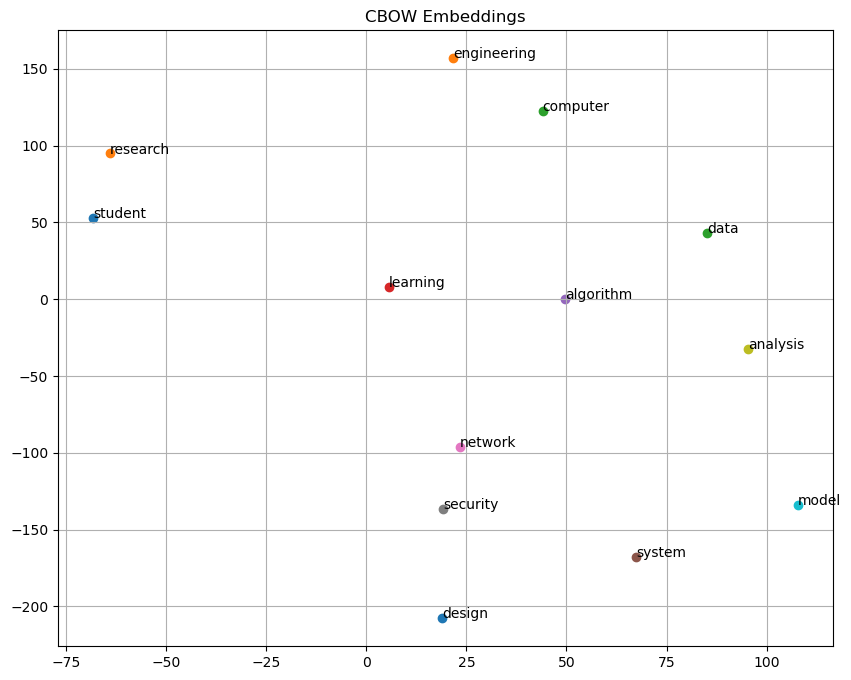

In [24]:
plot_embeddings(best_cbow[1], selected_words, "CBOW Embeddings")

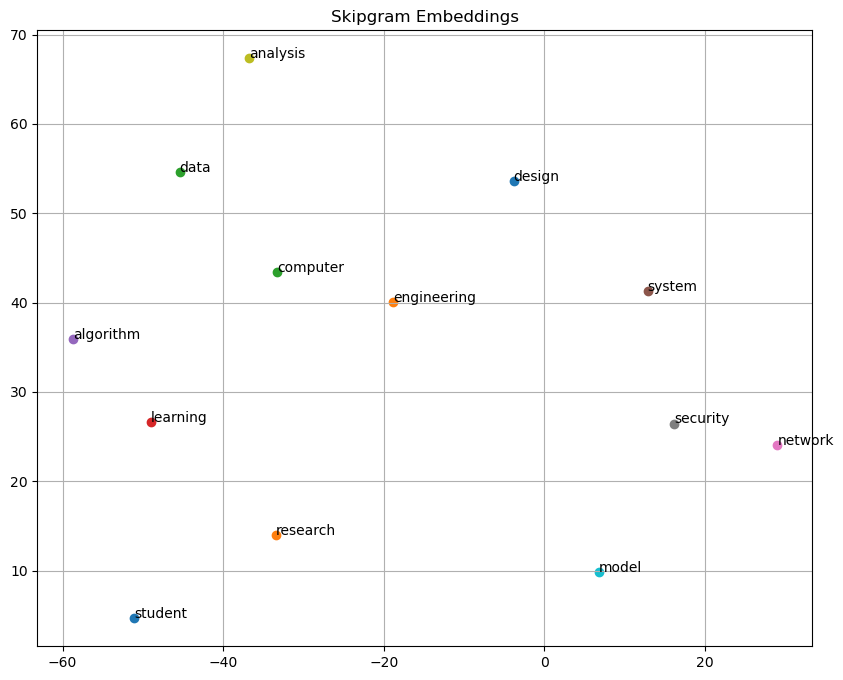

In [25]:
plot_embeddings(best_skip[1], selected_words, "Skipgram Embeddings")